In [1]:
%load_ext autoreload
%autoreload 2

import risk_kit as rk
import numpy as np
import pandas as pd

hfi = rk.get_hfi_returns()
hfi = hfi['2000':]

C:\Users\Yifei\anaconda_projects\Investment Management with Python and Machine Learning Specialization\risk_kit.py:42: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  hfi = pd.read_csv('data/edhec-hedgefundindices.csv',


In [2]:
q1 = (rk.var_gaussian(hfi['Distressed Securities'], level = 1) * 100).round(1)
q1

np.float64(3.1)

In [3]:
q2 = (rk.var_gaussian(hfi['Distressed Securities'], level = 1, modified = True) * 100).round(2)
q2

np.float64(4.97)

In [4]:
q3 = (rk.var_historic(hfi['Distressed Securities'], level = 1) * 100).round(2)
q3

np.float64(4.26)

In [5]:
ind = rk.get_ind_returns()
er = rk.annualize_rets(ind['2013':'2017'], 12)
cov = ind['2013':'2017'].cov()
l = ['Books', 'Steel', 'Oil', 'Mines']
n = len(l)
rf_rate = .1

C:\Users\Yifei\anaconda_projects\Investment Management with Python and Machine Learning Specialization\risk_kit.py:54: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  ind = pd.read_csv('data/ind30_m_vw_rets.csv',


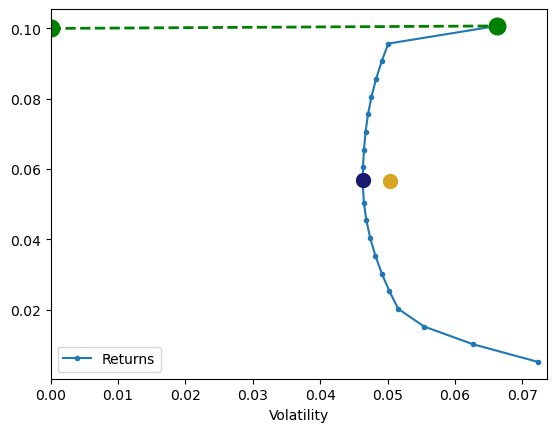

In [6]:
rk.plot_ef(20, er[l], cov.loc[l, l], show_cml = True, show_ew = True, show_gmv = True, riskfree_rate = rf_rate)

In [7]:
q4 = round(1 / n * 100, 1)
q4

25.0

In [8]:
q5 = (rk.msr(rf_rate, er[l], cov.loc[l, l]).max() * 100).round(1)
q5

np.float64(100.0)

In [9]:
w_msr = pd.Series((rk.msr(rf_rate, er[l], cov.loc[l, l]) * 100).round(2), index = er[l].index, name="w_msr")
q6 = w_msr.idxmax()
q6

'Steel'

In [10]:
q7 = len(w_msr[w_msr != 0])
q7

1

In [11]:
w_gmv = pd.Series((rk.gmv(cov.loc[l, l]) * 100).round(2), index = er[l].index, name="w_gmv")
q8 = w_gmv.max()
q8

47.7

In [12]:
q9 = w_gmv.idxmax()
q9

'Books'

In [13]:
q10 = len(w_gmv[w_gmv != 0])
q10

3

In [14]:
w_msr = rk.msr(rf_rate, er[l], cov.loc[l, l])
w_gmv = rk.gmv(cov.loc[l, l])

In [15]:
cov = ind['2018':].cov()

In [16]:
q11 = (rk.portfolio_vol(w_msr, cov.loc[l, l]) * 12**0.5 * 100).round(2)
q11

np.float64(21.98)

In [17]:
q12 = (rk.portfolio_vol(w_gmv, cov.loc[l, l]) * 12**0.5 * 100).round(2)
q12

np.float64(18.97)